# 07 — ABCD Mother Tracking Pilot

Run at most 10 skimmed ROOT files per background sample through the isolation-free SR/VR channels. The goal is to validate the `abcd_mother_tracking` histogram collection before mass production.

ABCD encoding: `0=A (pass, pass)`, `1=B (fail, pass)`, `2=C (pass, fail)`, `3=D (fail, fail)`.

In [1]:
import gc
import importlib
import os
import sys
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from coffea import processor

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.definitions import hists as hist_definitions
from sidm.tools import llpnanoaodschema, scaleout, sidm_processor, utilities

importlib.reload(hist_definitions)
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)

<module 'sidm.tools.scaleout' from '/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/scaleout.py'>

In [2]:
MAX_FILES_PER_SAMPLE = 10
USE_DASK = False

cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")
OUTPUT_DIR = study_dir / "ABCD_Mother_Tracking_Pilot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

channels = [
    "test_SR_2mu2e",
    "test_VR_2mu2e",
    "test_SR_4mu",
    "test_VR_4mu",
]

samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000",
    "QCD_Pt1000",
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50",
    "WW",
    "WZ",
    "ZZ",
]

ABCD_REGIONS = {"A": 0, "B": 1, "C": 2, "D": 3}
ABCD_HIST_NAMES = [
    f"{value_name}_{role}_abcd"
    for role in ("2mu2e_mulj", "2mu2e_egmlj", "4mu_mulj0", "4mu_mulj1")
    for value_name in (
        "fs_gen_id",
        "fs_gen_mother_id",
        "fs_e_gen_mother_id",
        "fs_mu_gen_mother_id",
        "fs_pho_gen_mother_id",
    )
]

assert len(ABCD_HIST_NAMES) == 20
missing_defs = [name for name in ABCD_HIST_NAMES if name not in hist_definitions.hist_defs]
assert not missing_defs, f"Missing histogram definitions: {missing_defs}"
print(f"Validated {len(ABCD_HIST_NAMES)} ABCD mother-tracking definitions")

Validated 20 ABCD mother-tracking definitions


In [3]:
client = None
if USE_DASK:
    client = scaleout.make_dask_client("tls://localhost:8786")
    executor = processor.DaskExecutor(client=client)
else:
    executor = processor.IterativeExecutor()

runner = processor.Runner(
    executor=executor,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=False,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["abcd_iso_base", "abcd_mother_tracking"],
    unweighted_hist=False,
)
client

In [4]:
fileset = utilities.make_fileset(
    samples_bkg,
    "skimmed_llpNanoAOD_v2",
    location_cfg="backgrounds.yaml",
    max_files=MAX_FILES_PER_SAMPLE,
)

file_rows = []
for sample, sample_fileset in fileset.items():
    sample_files = sample_fileset["files"]
    file_rows.append({"sample": sample, "n_files": len(sample_files)})
    print(f"{sample}: {len(sample_files)} files")
    for root_file in sample_files:
        print(f"  {root_file}")

pd.DataFrame(file_rows)

TTJets: 10 files
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_0.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_1.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_2.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_3.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_4.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_5.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_6.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_7.root
  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/TTJets_TuneCP5/skimmed_output1_8.root
  root://xcache//store/group/

,sample,n_files
0,TTJets,10
1,QCD_Pt15To20,10
2,QCD_Pt20To30,10
3,QCD_Pt30To50,10
4,QCD_Pt50To80,10
5,QCD_Pt80To120,10
6,QCD_Pt120To170,10
7,QCD_Pt170To300,10
8,QCD_Pt300To470,10
9,QCD_Pt470To600,10


## Pilot processing

Each sample is processed and saved independently. Existing output files are skipped by default so the cell can be resumed after a failure. Set `OVERWRITE = True` to rerun them.

In [5]:
OVERWRITE = False
processing_rows = []

for sample in samples_bkg:
    output_path = OUTPUT_DIR / f"{sample}.coffea"
    if output_path.exists() and not OVERWRITE:
        print(f"Skip existing output: {output_path}")
        processing_rows.append({"sample": sample, "status": "existing", "output": str(output_path)})
        continue

    print(f"Processing {sample}")
    sample_fileset = {sample: fileset[sample]}
    try:
        output = runner.run(
            sample_fileset,
            treename="Events",
            processor_instance=p,
        )
        coffea.util.save(output, output_path)
        processing_rows.append({"sample": sample, "status": "saved", "output": str(output_path)})
        print(f"Saved {output_path}")
    except Exception as error:
        processing_rows.append({"sample": sample, "status": f"ERROR: {error}", "output": str(output_path)})
        print(f"Failed {sample}: {error}")
    finally:
        output = None
        gc.collect()

processing_summary = pd.DataFrame(processing_rows)
processing_summary

Output()

Processing TTJets


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

ZZ is simulation. Scaling histograms or cutflows according to lumi*xs.
Saved /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/ABCD_Mother_Tracking_Pilot/ZZ.coffea


,sample,status,output
0,TTJets,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
1,QCD_Pt15To20,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
2,QCD_Pt20To30,ERROR: Failed to open file: [ERROR] Server res...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
3,QCD_Pt30To50,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
4,QCD_Pt50To80,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
5,QCD_Pt80To120,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
6,QCD_Pt120To170,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
7,QCD_Pt170To300,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
8,QCD_Pt300To470,saved,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...
9,QCD_Pt470To600,ERROR: Failed to open file: [ERROR] Server res...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...


## Output validation

Validate all 20 histogram keys and their axes. The table reports the sum of absolute bin weights in each region, avoiding accidental cancellation from negative MC weights. Empty regions are allowed in this small pilot.

In [6]:
validation_rows = []

for sample in samples_bkg:
    output_path = OUTPUT_DIR / f"{sample}.coffea"
    if not output_path.exists():
        validation_rows.append({"sample": sample, "status": "missing output"})
        continue

    loaded = coffea.util.load(output_path)
    sample_output = loaded.get("out", loaded)[sample]
    sample_hists = sample_output["hists"]
    missing_hists = [name for name in ABCD_HIST_NAMES if name not in sample_hists]
    if missing_hists:
        validation_rows.append({
            "sample": sample,
            "status": "missing histograms",
            "missing": ", ".join(missing_hists),
        })
        continue

    for histogram_name in ABCD_HIST_NAMES:
        histogram = sample_hists[histogram_name]
        axis_names = [axis.name for axis in histogram.axes]
        expected_pdg_axis = histogram_name.split("_2mu2e_")[0] if "_2mu2e_" in histogram_name else histogram_name.split("_4mu_")[0]
        expected_axes = ["channel", expected_pdg_axis, "abcd_region"]
        axes_ok = axis_names == expected_axes
        topology = "2mu2e" if "_2mu2e_" in histogram_name else "4mu"

        for channel in [name for name in channels if name.endswith(topology)]:
            for region, region_index in ABCD_REGIONS.items():
                region_hist = histogram[{
                    "channel": channel,
                    "abcd_region": hist.loc(region_index),
                }]
                abs_weight = float(np.abs(region_hist.values(flow=True)).sum())
                validation_rows.append({
                    "sample": sample,
                    "histogram": histogram_name,
                    "channel": channel,
                    "region": region,
                    "abs_weight": abs_weight,
                    "axes_ok": axes_ok,
                    "status": "ok" if axes_ok else f"bad axes: {axis_names}",
                })

    loaded = sample_output = sample_hists = None
    gc.collect()

validation = pd.DataFrame(validation_rows)
validation

,sample,histogram,channel,region,abs_weight,axes_ok,status
0,TTJets,fs_gen_id_2mu2e_mulj_abcd,test_SR_2mu2e,A,0.000000,True,ok
1,TTJets,fs_gen_id_2mu2e_mulj_abcd,test_SR_2mu2e,B,143.552004,True,ok
2,TTJets,fs_gen_id_2mu2e_mulj_abcd,test_SR_2mu2e,C,0.000000,True,ok
3,TTJets,fs_gen_id_2mu2e_mulj_abcd,test_SR_2mu2e,D,143.552004,True,ok
4,TTJets,fs_gen_id_2mu2e_mulj_abcd,test_VR_2mu2e,A,358.880011,True,ok
...,...,...,...,...,...,...,...
2239,ZZ,fs_pho_gen_mother_id_4mu_mulj1_abcd,test_SR_4mu,D,0.000000,True,ok
2240,ZZ,fs_pho_gen_mother_id_4mu_mulj1_abcd,test_VR_4mu,A,0.000000,True,ok
2241,ZZ,fs_pho_gen_mother_id_4mu_mulj1_abcd,test_VR_4mu,B,0.000000,True,ok
2242,ZZ,fs_pho_gen_mother_id_4mu_mulj1_abcd,test_VR_4mu,C,0.000000,True,ok


In [7]:
if "axes_ok" in validation:
    assert validation["axes_ok"].dropna().all(), "At least one histogram has unexpected axes"

region_summary = (
    validation[validation.get("status") == "ok"]
    .groupby(["sample", "channel", "region"], as_index=False)["abs_weight"]
    .sum()
)
region_summary

,sample,channel,region,abs_weight
0,DYJetsToLL_M10to50,test_SR_2mu2e,A,0.0
1,DYJetsToLL_M10to50,test_SR_2mu2e,B,0.0
2,DYJetsToLL_M10to50,test_SR_2mu2e,C,0.0
3,DYJetsToLL_M10to50,test_SR_2mu2e,D,0.0
4,DYJetsToLL_M10to50,test_SR_4mu,A,0.0
...,...,...,...,...
219,ZZ,test_VR_2mu2e,D,0.0
220,ZZ,test_VR_4mu,A,0.0
221,ZZ,test_VR_4mu,B,0.0
222,ZZ,test_VR_4mu,C,0.0


## Visual fill checks

Combine every available pilot output to make low-statistics validation plots. These plots use absolute bin weights and are intended only to verify that the ABCD and mother axes are populated.

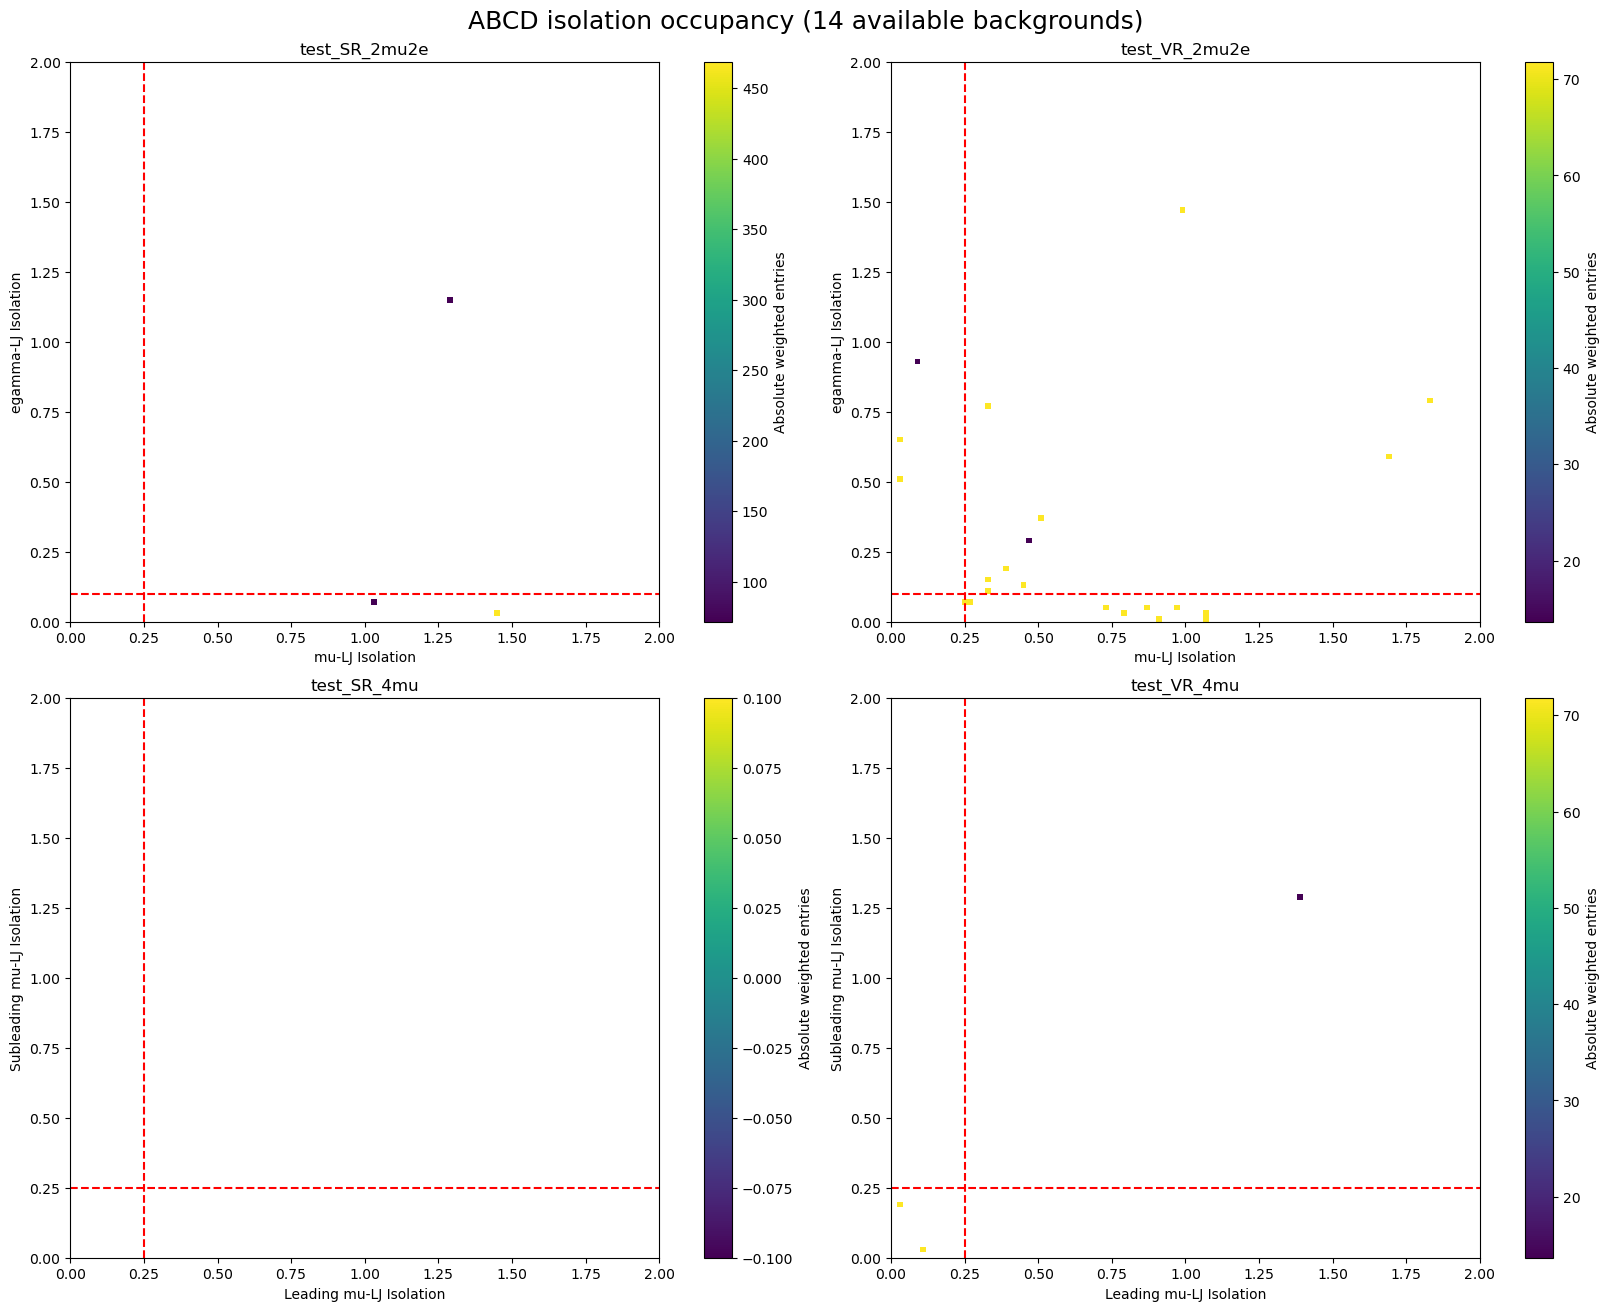

In [10]:
import matplotlib.pyplot as plt

def combined_histogram(histogram_name):
    total = None
    used_samples = []
    for output_path in sorted(OUTPUT_DIR.glob("*.coffea")):
        sample = output_path.stem
        loaded = coffea.util.load(output_path)
        sample_output = loaded.get("out", loaded)[sample]
        if histogram_name not in sample_output["hists"]:
            continue
        sample_histogram = sample_output["hists"][histogram_name]
        total = sample_histogram.copy() if total is None else total + sample_histogram
        used_samples.append(sample)
    if total is None:
        raise RuntimeError(f"No available histogram: {histogram_name}")
    return total, used_samples

plane_configs = [
    ("test_SR_2mu2e", "mulj_egmlj_iso", 0.25, 0.10),
    ("test_VR_2mu2e", "mulj_egmlj_iso", 0.25, 0.10),
    ("test_SR_4mu", "mulj_mulj_iso", 0.25, 0.25),
    ("test_VR_4mu", "mulj_mulj_iso", 0.25, 0.25),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 13), constrained_layout=True)
for ax, (channel, histogram_name, xcut, ycut) in zip(axes.flat, plane_configs):
    combined, used_samples = combined_histogram(histogram_name)
    plane = combined[{"channel": channel}]
    values = np.abs(plane.values(flow=False)).T
    xedges = np.asarray(plane.axes[0].edges)
    yedges = np.asarray(plane.axes[1].edges)
    mesh = ax.pcolormesh(xedges, yedges, np.ma.masked_less_equal(values, 0), shading="auto")
    ax.axvline(xcut, color="red", linestyle="--")
    ax.axhline(ycut, color="red", linestyle="--")
    ax.set(xlabel=plane.axes[0].label, ylabel=plane.axes[1].label, title=channel)
    fig.colorbar(mesh, ax=ax, label="Absolute weighted entries")
fig.suptitle(f"ABCD isolation occupancy ({len(used_samples)} available backgrounds)", fontsize=18)
plt.show()

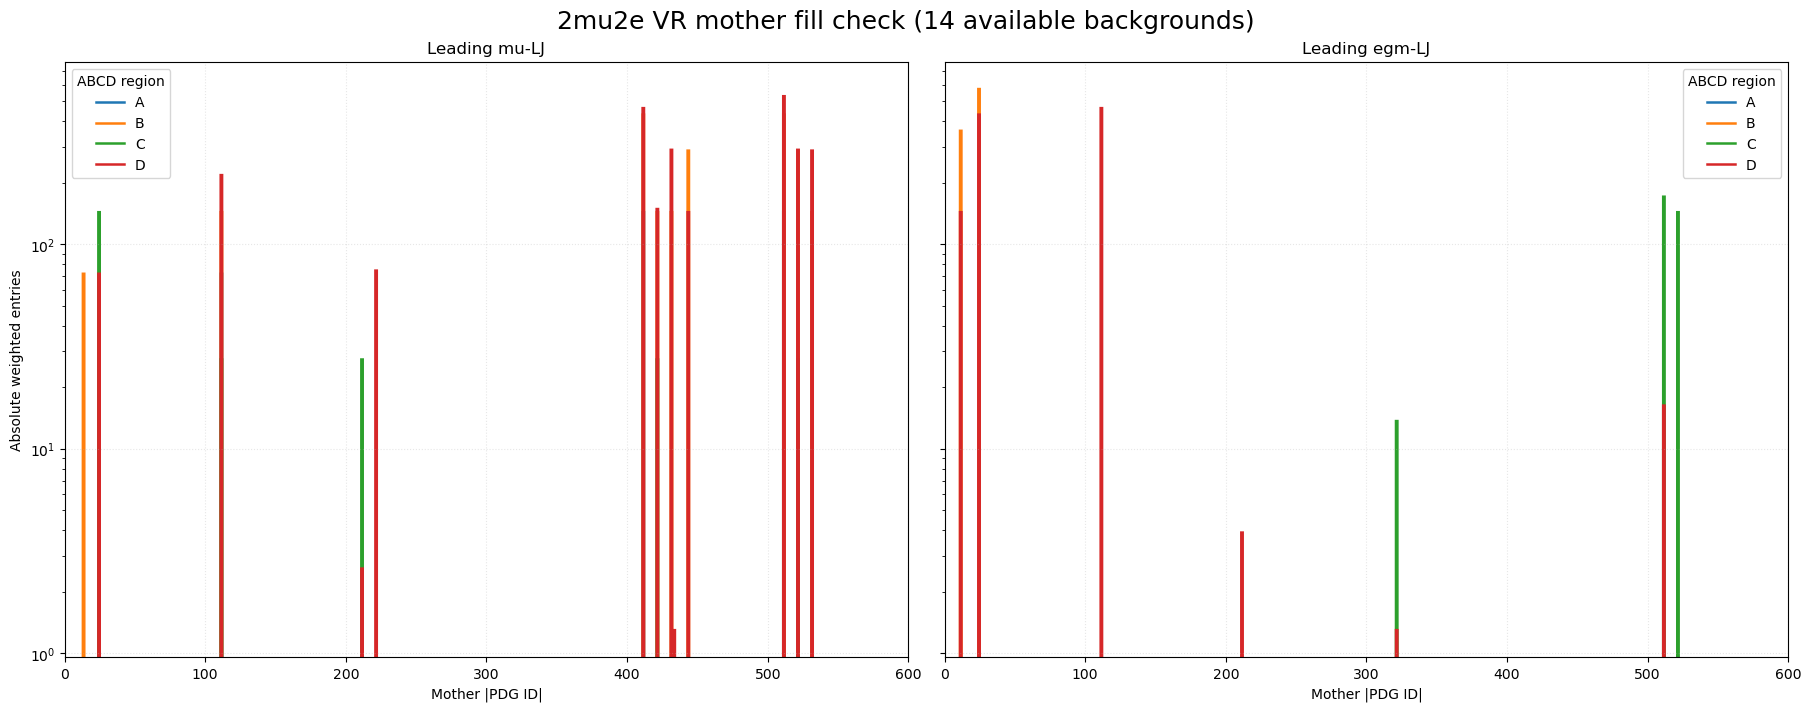

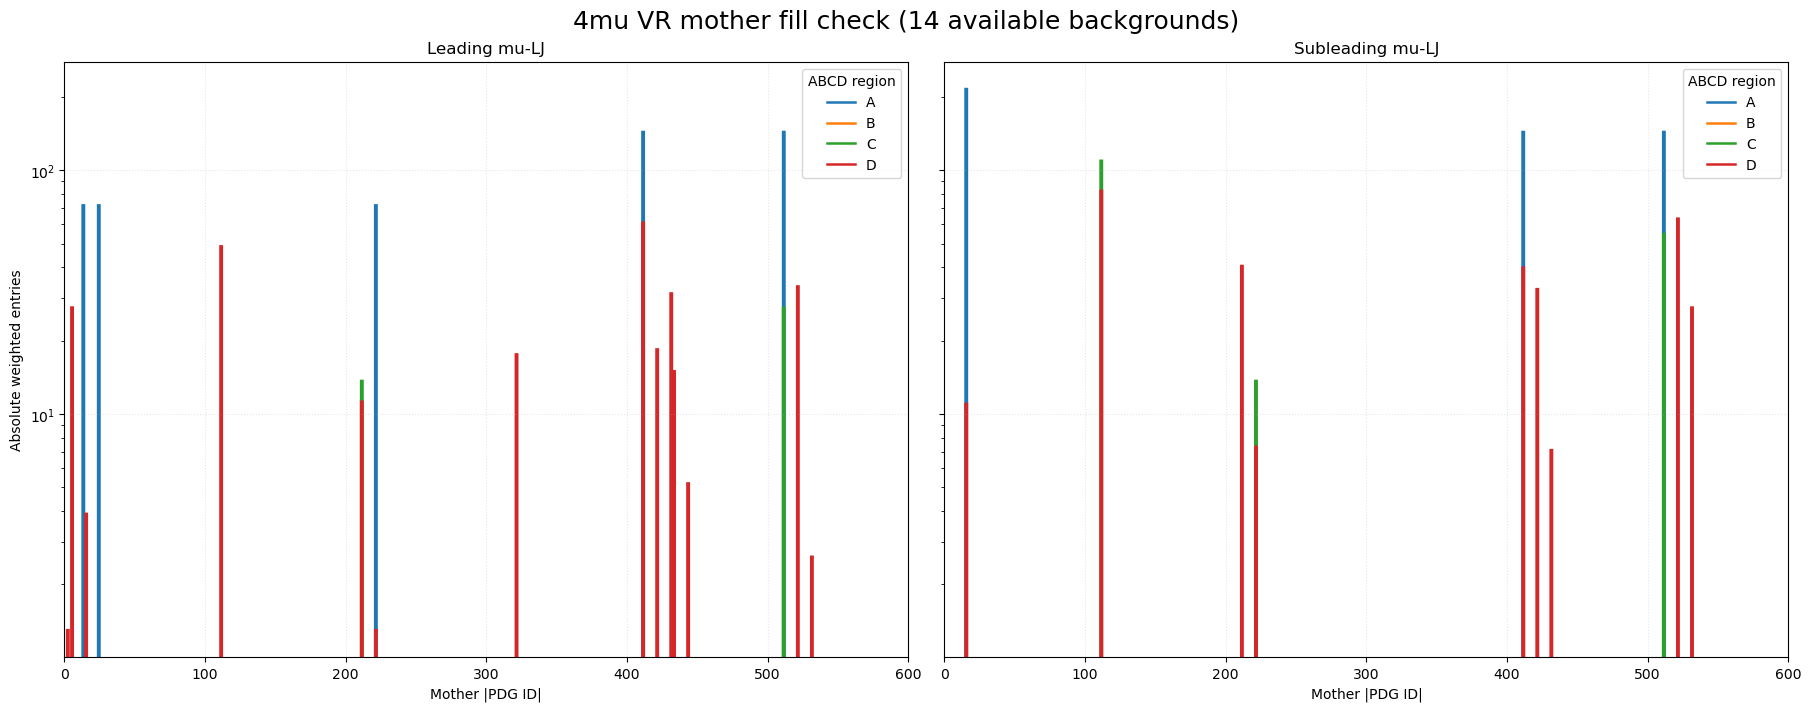

In [11]:
def plot_mother_regions(channel, histogram_names, role_labels, title):
    fig, axes = plt.subplots(1, len(histogram_names), figsize=(18, 7), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, histogram_name, role_label in zip(axes, histogram_names, role_labels):
        combined, used_samples = combined_histogram(histogram_name)
        for region, region_index in ABCD_REGIONS.items():
            projected = combined[{"channel": channel, "abcd_region": hist.loc(region_index)}]
            values = np.abs(projected.values(flow=False))
            ax.stairs(values, projected.axes[0].edges, label=region, linewidth=1.8)
        ax.set_yscale("log")
        ax.set_xlim(0, 600)
        ax.set_xlabel("Mother |PDG ID|")
        ax.set_title(role_label)
        ax.grid(True, linestyle=":", alpha=0.3)
        ax.legend(title="ABCD region")
    axes[0].set_ylabel("Absolute weighted entries")
    fig.suptitle(f"{title} ({len(used_samples)} available backgrounds)", fontsize=18)
    plt.show()

plot_mother_regions(
    "test_VR_2mu2e",
    ["fs_gen_mother_id_2mu2e_mulj_abcd", "fs_gen_mother_id_2mu2e_egmlj_abcd"],
    ["Leading mu-LJ", "Leading egm-LJ"],
    "2mu2e VR mother fill check",
)

plot_mother_regions(
    "test_VR_4mu",
    ["fs_gen_mother_id_4mu_mulj0_abcd", "fs_gen_mother_id_4mu_mulj1_abcd"],
    ["Leading mu-LJ", "Subleading mu-LJ"],
    "4mu VR mother fill check",
)